# Extended Data Figure 3 — Temporal trends in gene-measurement associations

Cumulative unique measurement-associated genes (top) and gene–measurement pairs (bottom)
discovered per year, as nested tiers of increasing inclusiveness:

1. **EUR common** — MAF $\geq 0.01$, studies where one ancestry reaches $\geq 90\%$ and it is
   non-Finnish European
2. **+ non-EUR common** — MAF $\geq 0.01$, studies where one ancestry reaches $\geq 90\%$ and it is
   **not** non-Finnish European (Finnish included)
3. **+ mixed common** — MAF $\geq 0.01$, studies where **no** single ancestry reaches $90\%$
   (pan-ancestry meta-analyses)
4. **+ rare** — MAF $< 0.01$, any ancestry

Each bar segment is the increment that tier adds over the tiers below it.

> **Revised for reviewer round 1.** The published version used a binary ancestry split
> (`nfe_common` / `non_nfe_common`), which put pan-ancestry meta-analyses and FinnGen in the same
> bucket as genuinely non-European studies. `mixed` is now its own layer. See
> `chapters/06-review-r1/ancestry-mixed-split/` for the reclassification and the numbers.

**Data:** `ed3_cumulative_discovery.csv`, written by
`chapters/02-analysis-main/01_panoramic.ipynb`. That is the only input; the tier counts are
computed there, alongside the Figure 1c version of the same curves, so the two cannot disagree.
No Spark session is needed here.

## Changelog — reviewer round 1

What changed relative to the published version of this notebook.

| # | Published version | Now |
| - | ----------------- | --- |
| 1 | **Three** stacked layers: `nfe_common`, `non_nfe_common`, rare | **Four** layers: `EUR common`, `non-EUR common`, `mixed common`, rare |
| 2 | Ancestry was binary — anything not $\geq 90\%$ non-Finnish European counted as "non-EUR", so pan-ancestry meta-analyses and FinnGen sat with genuinely non-European studies | `mixed` (no single ancestry $\geq 90\%$) is its own layer; `non-EUR` now means one ancestry $\geq 90\%$ and it is not NFE, Finnish included |
| 3 | Read `list_of_prioritised_genes_per_CS_with_year_nfe_maf.parquet` through a 40 GB PySpark session | Reads `l2g_measurements_full-r1.csv` with pandas — no Spark, no Java, runs in seconds |
| 4 | Layer heights computed inline with no verification | Tier counts come from `01_panoramic.ipynb`; this notebook only reshapes and draws them, and checks that the layers sum to the top tier |
| 5 | `ffill().fillna(0)` on reindexed cumulative counts | Fixed year axis 2006–2024 with `cumsum` over per-year counts, so a year with no discoveries carries the previous total instead of dropping out |
| 6 | No numbers printed | Final-year tier totals, layer heights and layer percentages printed at the end |

**Unchanged:** panel layout (genes on top, gene–measurement pairs below), pair definition
(`geneId` $\times$ `studyId`), colours for the EUR / non-EUR / rare layers, MAF threshold 0.01,
ancestry threshold 90%, exclusion of 2025.

**Output file.** `extended_figure_3.pdf`, in this directory.

**Effect on the figure.** Totals are identical to the published version — 15,061 genes and 358,449
pairs at 2024, and the EUR-common bottom layer is unchanged at 13,914 genes. Only the old single
"non-EUR" band splits in two: for genes, 723 (4.8%) genuinely non-EUR and 293 (2.0%) mixed; for
pairs, 30,553 (8.5%) non-EUR and 68,188 (19.0%) mixed.

## Setup

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

In [2]:
from manuscript_methods import paper

figure_dir = str(paper.ROOT / "chapters" / "05-figures-supplementary" / "extended_data")

# The nested-tier discovery counts are computed once, in
# chapters/02-analysis-main/01_panoramic.ipynb, which is also where Figure 1c gets its version of
# them. This notebook only reshapes and draws them.
discovery_path = paper.derived("ed3_cumulative_discovery.csv")

MAX_YEAR = 2024  # 2025 is a partial year
FIRST_YEAR = 2006

# Nesting order of the stacked layers, bottom to top.
ANCESTRY_ORDER = ["EUR", "non-EUR", "mixed"]
ANCESTRY_COLORS = {"EUR": "#4472C4", "non-EUR": "#70AD47", "mixed": "#ED7D31", "rare": "#FFC000"}
LAYER_LABELS = {
    "EUR": r"EUR common (MAF $\geq$ 0.01)",
    "non-EUR": r"Non-EUR common (MAF $\geq$ 0.01)",
    "mixed": r"Mixed ancestry common (MAF $\geq$ 0.01)",
    "rare": r"Rare (MAF $<$ 0.01)",
}
# The upstream table labels the tiers by what they add; these are the short names used here.
TIER_FROM_LABEL = {
    "EUR common": "EUR",
    "non-EUR common": "non-EUR",
    "mixed common": "mixed",
    "rare": "rare",
}

## Load gene–measurement associations

In [3]:
discovery = pd.read_csv(discovery_path)
print(f"rows: {len(discovery):,}  metrics: {sorted(discovery['metric'].unique())}")
discovery.head(3)

rows: 152  metrics: ['gene-measurement pairs (studyId)', 'measurement genes']


,metric,tier,tier_index,layer_label,year,count,cumulative,layer
0,measurement genes,EUR (common),1,EUR common,2006,1,1,1.0
1,measurement genes,EUR (common),1,EUR common,2007,4,5,5.0
2,measurement genes,EUR (common),1,EUR common,2008,46,51,51.0


## Cumulative discovery per nested tier

In [4]:
def tier_table(discovery: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Reshape the upstream nested-tier counts into the wide form the panels draw.

    Args:
        discovery: the `ed3_cumulative_discovery.csv` table.
        metric: which entity to select, `measurement genes` or
            `gene-measurement pairs (studyId)`.

    Returns:
        pandas.DataFrame: indexed by year, one cumulative column per tier plus one
        `layer_` column per stacked segment.
    """
    sub = discovery[discovery["metric"] == metric].copy()
    sub["tier"] = sub["layer_label"].map(TIER_FROM_LABEL)
    order = ANCESTRY_ORDER + ["rare"]
    cumulative = sub.pivot(index="year", columns="tier", values="cumulative")[order]
    layers = sub.pivot(index="year", columns="tier", values="layer")[order]
    table = cumulative.join(layers.add_prefix("layer_"))
    return table.loc[FIRST_YEAR:MAX_YEAR]


genes = tier_table(discovery, "measurement genes")
pairs = tier_table(discovery, "gene-measurement pairs (studyId)")
genes

tier,EUR,non-EUR,mixed,rare,layer_EUR,layer_non-EUR,layer_mixed,layer_rare
year,,,,,,,,
2006,1,1,1,1,1.0,0.0,0.0,0.0
2007,5,5,5,5,5.0,0.0,0.0,0.0
2008,51,51,52,52,51.0,0.0,1.0,0.0
2009,190,195,196,196,190.0,5.0,1.0,0.0
2010,321,341,342,342,321.0,20.0,1.0,0.0
2011,467,503,525,525,467.0,36.0,22.0,0.0
2012,570,623,701,701,570.0,53.0,78.0,0.0
2013,697,760,861,861,697.0,63.0,101.0,0.0
2014,1045,1133,1231,1231,1045.0,88.0,98.0,0.0


In [5]:
# The tiers are nested, so the stacked layer heights must add up to the top tier, and each tier
# must be at least as large as the one below it. This replaces a check against a pre-refactor
# baseline file, which pinned the notebook to one data vintage and would have failed on any
# legitimate upstream change.
for metric, table in [("measurement genes", genes), ("gene-measurement pairs (studyId)", pairs)]:
    order = ANCESTRY_ORDER + ["rare"]
    stacked = table[[f"layer_{tier}" for tier in order]].sum(axis=1)
    assert np.allclose(stacked, table["rare"]), f"{metric}: layers do not sum to the top tier"
    assert (table[order].diff(axis=1).drop(columns=order[0]) >= -1e-9).to_numpy().all(), (
        f"{metric}: tiers are not nested"
    )
    print(f"{metric}: layers sum to the top tier, tiers nested | {int(table['rare'].loc[MAX_YEAR]):,} at {MAX_YEAR}")

measurement genes: layers sum to the top tier, tiers nested | 15,061 at 2024
gene-measurement pairs (studyId): layers sum to the top tier, tiers nested | 358,449 at 2024


## Extended Data Figure 3

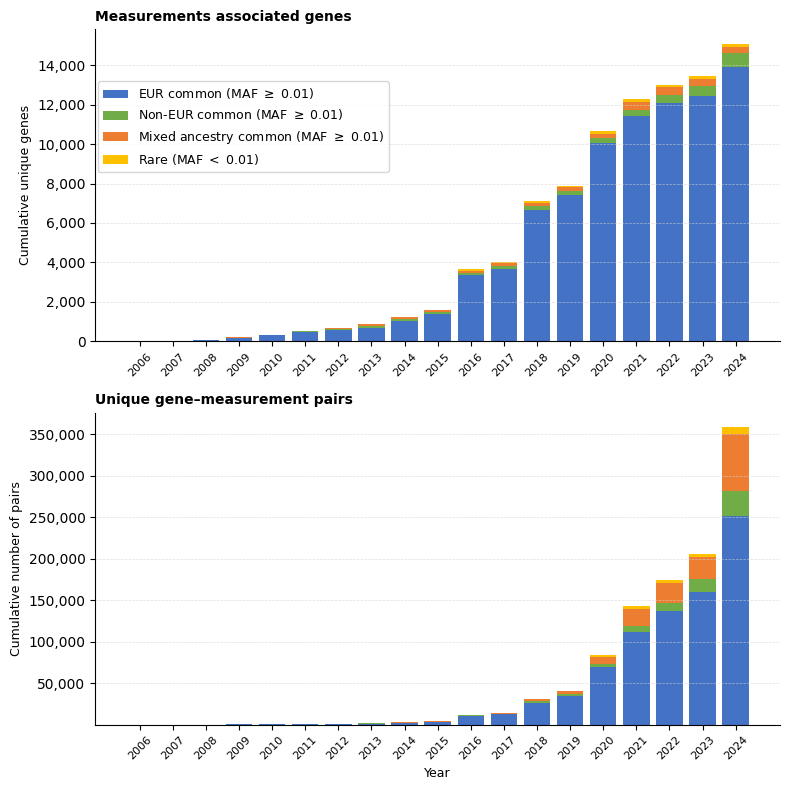

In [6]:
def make_stacked_bar_panel(ax: plt.Axes, table: pd.DataFrame, ylabel: str) -> None:
    """Stacked bar chart of cumulative discovery: EUR / non-EUR / mixed / rare layers.

    Args:
        ax: axes to draw on.
        table: output of `cumulative_layers`.
        ylabel: y-axis label.
    """
    x = [str(year) for year in table.index]
    bottom = np.zeros(len(table))
    for layer in ANCESTRY_ORDER + ["rare"]:
        height = table[f"layer_{layer}"].to_numpy()
        ax.bar(x, height, bottom=bottom, color=ANCESTRY_COLORS[layer], label=LAYER_LABELS[layer])
        bottom = bottom + height

    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

make_stacked_bar_panel(ax1, genes, "Cumulative unique genes")
ax1.set_title("Measurements associated genes", fontsize=10, fontweight="bold", loc="left")
ax1.set_xlabel("")

make_stacked_bar_panel(ax2, pairs, "Cumulative number of pairs")
ax2.set_title("Unique gene\u2013measurement pairs", fontsize=10, fontweight="bold", loc="left")
ax2.set_xlabel("Year", fontsize=9)

# Legend above both panels
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.9), ncols=1)

fig.tight_layout()
fig.savefig(f"{figure_dir}/extended_figure_3.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Numbers behind the figure

In [7]:
summary = pd.DataFrame(
    {
        "genes_cumulative": genes.loc[MAX_YEAR, ANCESTRY_ORDER + ["rare"]],
        "genes_layer": genes.loc[MAX_YEAR, [f"layer_{a}" for a in ANCESTRY_ORDER + ["rare"]]].to_numpy(),
        "pairs_cumulative": pairs.loc[MAX_YEAR, ANCESTRY_ORDER + ["rare"]],
        "pairs_layer": pairs.loc[MAX_YEAR, [f"layer_{a}" for a in ANCESTRY_ORDER + ["rare"]]].to_numpy(),
    }
).astype(int)
summary["genes_layer_pct"] = (100 * summary["genes_layer"] / genes.loc[MAX_YEAR, "rare"]).round(2)
summary["pairs_layer_pct"] = (100 * summary["pairs_layer"] / pairs.loc[MAX_YEAR, "rare"]).round(2)
summary

,genes_cumulative,genes_layer,pairs_cumulative,pairs_layer,genes_layer_pct,pairs_layer_pct
tier,,,,,,
EUR,13914,13914,251690,251690,92.38,70.22
non-EUR,14637,723,282243,30553,4.80,8.52
mixed,14930,293,350431,68188,1.95,19.02
rare,15061,131,358449,8018,0.87,2.24
